# 03 - Ant Colony Optimization

Ant Colony Optimization (ACO) es una metaheuristica poblacional inspirada en el comportamiento de colonias de hormigas. Varias soluciones se construyen en paralelo y dejan **feromona** sobre los componentes buenos para guiar futuras construcciones.


## 1. Idea general

Cada hormiga arma una solucion paso a paso. En un problema de rutas, desde la ciudad actual elige la siguiente ciudad con una probabilidad que combina:

- **Feromona**: memoria colectiva de buenas rutas previas.
- **Heuristica local**: informacion inmediata, por ejemplo `1 / distancia`.
- **Evaporacion**: reduce feromona antigua para evitar convergencia prematura.

La regla tipica pondera feromona con `alpha` e informacion heuristica con `beta`.


## 2. Codigo base generico para rutas

Esta implementacion es un motor ACO para problemas representados por una matriz de costos, como TSP. Minimiza la longitud de una ruta cerrada.


In [1]:
import math
import itertools
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)


def make_tsp_instance(n=20, seed=42):
    """Crea una instancia reproducible de ciudades en el plano [0, 1] x [0, 1]."""
    rng = np.random.default_rng(seed)
    return rng.random((n, 2))


def distance_matrix(coords):
    """Calcula la matriz de distancias euclidianas entre ciudades."""
    diff = coords[:, None, :] - coords[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def tour_length(tour, D):
    """Costo total de una ruta cerrada que vuelve al punto inicial."""
    return float(sum(D[tour[i], tour[(i + 1) % len(tour)]] for i in range(len(tour))))


def plot_tour(coords, tour, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    closed = list(tour) + [tour[0]]
    xy = coords[closed]
    ax.plot(xy[:, 0], xy[:, 1], marker="o", linewidth=1.8)
    for idx, (x, y) in enumerate(coords):
        ax.text(x + 0.008, y + 0.008, str(idx), fontsize=8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")
    return ax


def plot_convergence(history, title, ylabel="Mejor costo", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(history, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Iteracion")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    return ax


In [2]:
def ant_colony_tsp(D, n_ants=35, n_iter=90, alpha=1.0, beta=3.0, rho=0.35, q=1.0, seed=0):
    """Ant Colony Optimization para TSP con matriz de distancias."""
    rng = np.random.default_rng(seed)
    n = len(D)
    pheromone = np.ones((n, n))
    heuristic = 1 / (D + np.eye(n))
    np.fill_diagonal(heuristic, 0)

    best_tour = None
    best_cost = float("inf")
    history = []

    for _ in range(n_iter):
        tours = []
        costs = []

        for _ant in range(n_ants):
            start = int(rng.integers(n))
            tour = [start]
            unvisited = set(range(n)) - {start}

            while unvisited:
                i = tour[-1]
                choices = np.array(sorted(unvisited))
                desirability = (pheromone[i, choices] ** alpha) * (heuristic[i, choices] ** beta)
                probs = desirability / desirability.sum()
                nxt = int(rng.choice(choices, p=probs))
                tour.append(nxt)
                unvisited.remove(nxt)

            tour = np.array(tour)
            c = tour_length(tour, D)
            tours.append(tour)
            costs.append(c)

            if c < best_cost:
                best_cost = c
                best_tour = tour.copy()

        pheromone *= (1 - rho)
        for tour, c in zip(tours, costs):
            deposit = q / c
            for i in range(n):
                a = tour[i]
                b = tour[(i + 1) % n]
                pheromone[a, b] += deposit
                pheromone[b, a] += deposit

        history.append(best_cost)

    return best_tour, best_cost, history, pheromone


## 3. Ejemplo: TSP

Usamos una instancia reproducible de 20 ciudades. Cada hormiga construye una ruta completa; al final de cada iteracion se evapora feromona y luego se deposita mas feromona en las rutas cortas.


In [3]:
coords = make_tsp_instance(n=20, seed=42)
D = distance_matrix(coords)

best_tour, best_len, history, pheromone = ant_colony_tsp(
    D, n_ants=40, n_iter=100, alpha=1.0, beta=3.0, rho=0.30, q=1.0, seed=10
)

print(f"Mejor longitud encontrada por ACO: {best_len:.3f}")
print(f"Mejor ruta: {best_tour.tolist()}")
print(f"Iteraciones: {len(history)}")


Mejor longitud encontrada por ACO: 3.416
Mejor ruta: [0, 10, 12, 8, 13, 17, 7, 16, 4, 18, 19, 14, 2, 5, 6, 3, 15, 11, 1, 9]
Iteraciones: 100


### Explicacion general del codigo ejemplo

1. La matriz `D` contiene las distancias entre ciudades.
2. Cada hormiga comienza en una ciudad aleatoria y va escogiendo ciudades no visitadas.
3. La probabilidad de elegir una ciudad aumenta si la arista tiene mucha feromona o es corta.
4. Despues de cada generacion, `rho` evapora la feromona.
5. Las rutas mas cortas depositan mas feromona porque `deposit = q / costo`.


<notebook-cell>:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


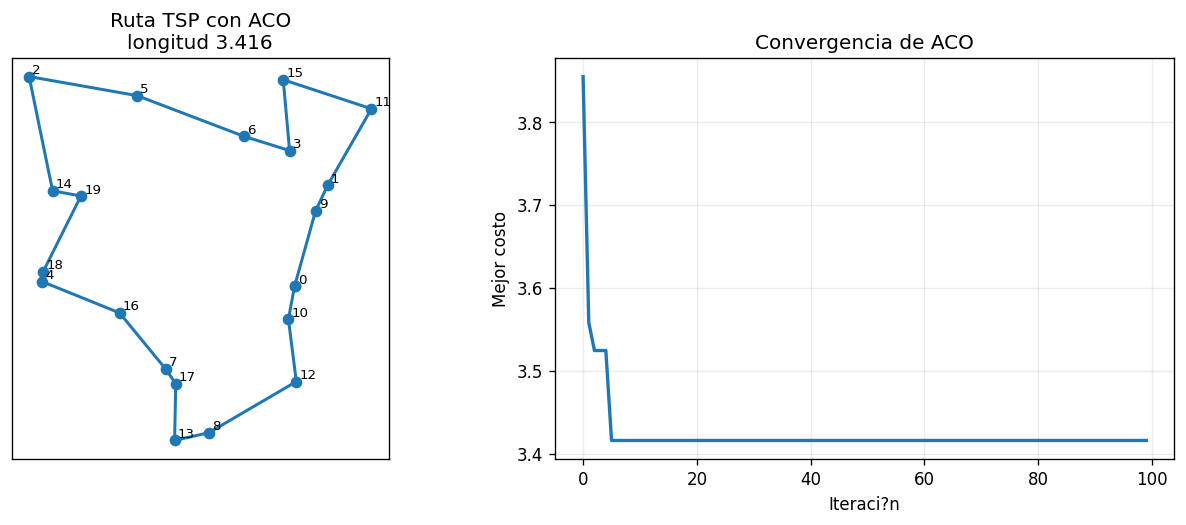

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_tour(coords, best_tour, f"Ruta TSP con ACO\nlongitud {best_len:.3f}", ax=axes[0])
plot_convergence(history, "Convergencia de ACO", ax=axes[1])
plt.tight_layout()
plt.show()


<notebook-cell>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


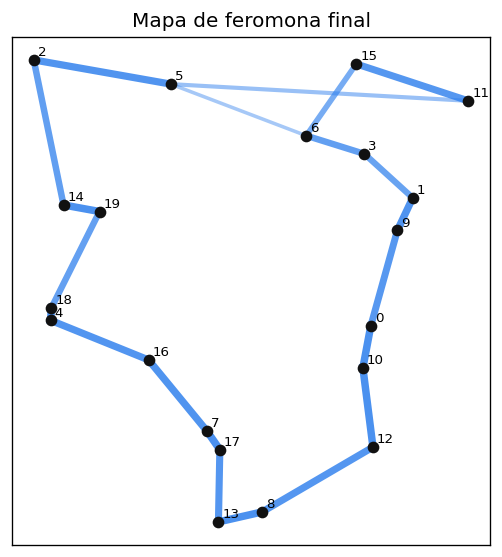

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(coords[:, 0], coords[:, 1], color="#111", zorder=3)
max_ph = pheromone.max()
for i in range(len(coords)):
    for j in range(i + 1, len(coords)):
        strength = pheromone[i, j] / max_ph
        if strength > 0.18:
            ax.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color="#2f80ed",
                alpha=0.12 + 0.75 * strength,
                linewidth=0.5 + 4 * strength,
            )
for i, (x, y) in enumerate(coords):
    ax.text(x + 0.008, y + 0.008, str(i), fontsize=8)
ax.set_title("Mapa de feromona final")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal", adjustable="box")
plt.show()


## 4. Parametros, ventajas y limites

`alpha` controla cuanto se sigue la feromona; `beta` controla cuanto pesa la informacion local; `rho` define que tan rapido se olvida. Si la evaporacion es muy baja, la colonia puede converger demasiado pronto; si es muy alta, la memoria colectiva se debilita.
